In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2
import pandas as pd
from sklearn.datasets import load_files


# ══════════════════════════════════════════════════════════════
# PART 1 — Helper Functions: IoU and NMS
# ══════════════════════════════════════════════════════════════


In [8]:


def IoU(boxA, boxB):
    """Compute Intersection over Union between two boxes [x1, y1, x2, y2]."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Area of intersection rectangle
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    # Area of each individual box
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)

    # IoU = intersection / union
    iou = float(interArea) / float(boxAArea + boxBArea - interArea)
    return iou


def NMS(boxes, overlapThresh):
    """Non-Maximum Suppression: removes redundant overlapping boxes."""
    if len(boxes) == 0:
        return []

    if boxes.dtype.kind == "i":
        boxes = boxes.astype("float")

    pick = []

    x1 = boxes[:, 0]  # top-left x of all boxes
    y1 = boxes[:, 1]  # top-left y of all boxes
    x2 = boxes[:, 2]  # bottom-right x of all boxes
    y2 = boxes[:, 3]  # bottom-right y of all boxes

    area = (x2 - x1 + 1) * (y2 - y1 + 1)  # width * height of each box
    idxs = np.argsort(y2)                   # sort boxes by bottom-right y (ascending)

    while len(idxs) > 0:
        last = len(idxs) - 1   # index of the last (highest) box in sorted order
        i = idxs[last]
        pick.append(i)

        # Compute intersection coordinates with all remaining boxes
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.maximum(x2[i], x2[idxs[:last]])
        yy2 = np.maximum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        overlap = (w * h) / area[idxs[:last]]

        # Delete current box and all boxes with overlap above threshold
        idxs = np.delete(
            idxs, np.concatenate(([last], np.where(overlap > overlapThresh)[0]))
        )

    return boxes[pick]

# ── Quick demo of IoU and NMS ──
boxes = np.array([[12,  84, 140, 212],
                  [24,  84, 152, 212],
                  [36,  84, 164, 212],
                  [12,  96, 140, 224],
                  [24,  96, 152, 224],
                  [24, 108, 152, 236],
                  [12, 120, 140, 248],
                  [36, 120, 164, 248],
                  [24, 132, 152, 260],
                  [36, 132, 164, 260]])

print("Original boxes:")
print(boxes)

nms_boxes = NMS(boxes, overlapThresh=0.3)
print("\nBoxes after NMS:")
print(nms_boxes)

boxA = [12, 84, 140, 212]
boxB = [24, 84, 152, 212]
iou_value = IoU(boxA, boxB)
print(f"\nIoU between boxA and boxB: {iou_value:.4f}")



Original boxes:
[[ 12  84 140 212]
 [ 24  84 152 212]
 [ 36  84 164 212]
 [ 12  96 140 224]
 [ 24  96 152 224]
 [ 24 108 152 236]
 [ 12 120 140 248]
 [ 36 120 164 248]
 [ 24 132 152 260]
 [ 36 132 164 260]]

Boxes after NMS:
[[ 36. 132. 164. 260.]]

IoU between boxA and boxB: 0.8298


In [9]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, 'ximgproc'))

4.10.0
True


# ══════════════════════════════════════════════════════════════
# PART 2 — Selective Search  (Region Proposals)
# ══════════════════════════════════════════════════════════════


(3184, 5404, 3)
(512, 512, 3)


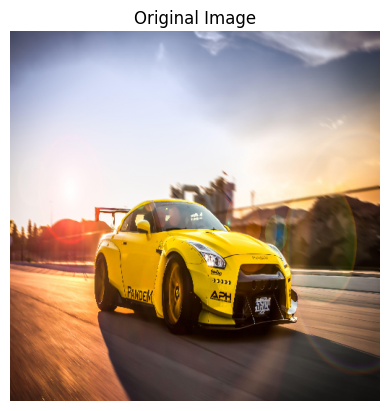

Total Regions generated: 5073


In [10]:

img = cv2.imread('1238127.jpg')
print(img.shape)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))
print(img.shape)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()

#Calculate ROI proposals using Selective Search
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img)
ss.switchToSelectiveSearchQuality()   # quality mode (slower but more proposals)
rects = ss.process()
print(f'Total Regions generated: {len(rects)}')

# Draw proposals in batches of 100 at a time
for i in range(0, len(rects), 100):
    output = img.copy()
    for (x, y, w, h) in rects[i:i + 100]:
        color = [random.randint(0, 255) for j in range(3)]
        cv2.rectangle(output, (x, y), (x + w, y + h), tuple(color), 2)
    cv2.imshow('Output', output)
    key = cv2.waitKey(0)
    if key == 27:  # ESC key to stop
        break
cv2.destroyAllWindows()



# ══════════════════════════════════════════════════════════════
# PART 3 — Data Preparation: Read Annotations + Generate Dataset
# ══════════════════════════════════════════════════════════════


In [12]:
def load_data():
    """Load car/no-car image dataset from Used_cars/ directory."""
    data = load_files('Used_cars/')
    filenames = np.array(data['filenames'])
    x = []
    y = []
    not_count = 0
    for name in filenames:
        if 'No' in name:
            not_count += 1
            if not_count < 2300:
                img_file = cv2.imread(name)
                x.append(img_file)
                y.append(0)
            else:
                pass
        else:
            img_file = cv2.imread(name)
            x.append(img_file)
            y.append(1)
    x = np.asarray(x)
    y = np.asarray(y)
    return x, y


if __name__ == "__main__":
    # ── Read annotation CSV ──
    data     = pd.read_csv('numberplates/annotations.csv')
    allnames = data.iloc[:, [0]].values
    box_list = data.iloc[:, [3, 4, 5, 6]]
    allnames = np.ndarray.flatten(allnames)
    print(allnames)
    print(box_list)

    car_save_path    = 'Used_cars/plate/'
    no_car_save_path = 'Used_cars/no_plate/'

    total_car    = 0
    total_no_car = 0

    for i in range(len(allnames)):          # for each annotated image
        file     = allnames[i]              # e.g. car0.png
        ss       = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
        img_file = cv2.imread('numberplates/' + file)
        img_copy = img_file.copy()
        ss.setBaseImage(img_file)
        ss.switchToSelectiveSearchFast()    # fast mode for large-scale processing
        results = ss.process()              # RoI proposals (x, y, w, h)

        car_count    = 0
        no_car_count = 0
        total_counted = 0

        for box in results:                 # for every RoI proposal
            # Convert from (x, y, w, h) → (x1, y1, x2, y2)
            found_box_use = [box[0], box[1], box[0] + box[2], box[1] + box[3]]
            image_roi     = img_copy[box[1]:box[1] + box[3], box[0]:box[0] + box[2]]
            iou           = IoU(found_box_use, box_list.iloc[i].values)

            if iou > 0.7 and car_count < 16:
                # High IoU → positive (plate) sample
                image_roi_use = cv2.resize(image_roi, (128, 128))
                image_roi_use = image_roi_use.reshape((128, 128, 3))
                cv2.imwrite(car_save_path + 'Plate' + str(total_car) + '.png', image_roi_use)
                car_count  += 1
                total_car  += 1
            elif iou < 0.3 and no_car_count < 16:
                # Low IoU → negative (no plate) sample
                image_roi_use = cv2.resize(image_roi, (128, 128))
                image_roi_use = image_roi_use.reshape((128, 128, 3))
                cv2.imwrite(no_car_save_path + 'No_Plate' + str(total_no_car) + '.png', image_roi_use)
                no_car_count  += 1
                total_no_car  += 1

            if total_counted > 999:
                break
            total_counted += 1
        # 32 samples × 50 images = 1600 total samples

    x, y = load_data()
    print(x.shape)
    print(y.shape)

['Cars0.png' 'Cars1.png' 'Cars2.png' 'Cars3.png' 'Cars4.png' 'Cars5.png'
 'Cars6.png' 'Cars7.png' 'Cars8.png' 'Cars9.png' 'Cars10.png' 'Cars11.png'
 'Cars12.png' 'Cars13.png' 'Cars14.png' 'Cars15.png' 'Cars16.png'
 'Cars17.png' 'Cars18.png' 'Cars19.png' 'Cars20.png' 'Cars21.png'
 'Cars22.png' 'Cars23.png' 'Cars24.png' 'Cars25.png' 'Cars26.png'
 'Cars27.png' 'Cars28.png' 'Cars29.png' 'Cars30.png' 'Cars31.png'
 'Cars32.png' 'Cars33.png' 'Cars34.png' 'Cars35.png' 'Cars36.png'
 'Cars37.png' 'Cars38.png' 'Cars39.png' 'Cars40.png' 'Cars41.png'
 'Cars42.png' 'Cars43.png' 'Cars44.png' 'Cars45.png' 'Cars46.png'
 'Cars47.png' 'Cars48.png' 'Cars49.png' 'Cars50.png']
     xmin   ymin   xmax   ymax
0   181.0  140.0  335.0  194.0
1   134.0  155.0  262.0  194.0
2   229.0  132.0  270.0  145.0
3   142.0  171.0  261.0  209.0
4   106.0   70.0  341.0  217.0
5   226.0  222.0  242.0  244.0
6    90.0   91.0  298.0  191.0
7   166.0  152.0  206.0  166.0
8   163.0  134.0  243.0  173.0
9   148.0  202.0  246.0  2